In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
sns.set(style="whitegrid")

In [2]:
# Path tới file (từ thư mục func/)
filepath = '../dataoutput_dataset.jsonl'
# Thử đọc bằng pandas (json lines)
try:
    df = pd.read_json(filepath, lines=True)
except Exception as e:
    print('pd.read_json failed:', e)
    # fallback: load line-by-line
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except Exception as e2:
                # skip malformed line
                print('skip line:', e2)
    df = pd.DataFrame.from_records(records)

print('Loaded rows:', len(df))
df.head()

Loaded rows: 1865


,vul_id,file,method,version,label,code
0,VUL4J-1,src/main/java/com/alibaba/fastjson/serializer/...,deserialze,vulnerable,1,"@SuppressWarnings({ ""unchecked"", ""rawtypes"" })..."
1,VUL4J-1,src/main/java/com/alibaba/fastjson/serializer/...,deserialze,fixed,0,"@SuppressWarnings({ ""unchecked"", ""rawtypes"" })..."
2,VUL4J-1,src/main/java/com/alibaba/fastjson/serializer/...,toObjectArray,vulnerable_other,0,"@SuppressWarnings(""unchecked"")\r\n private ..."
3,VUL4J-1,src/main/java/com/alibaba/fastjson/serializer/...,ObjectArrayCodec,vulnerable_other,0,public ObjectArrayCodec(){\r\n }
4,VUL4J-1,src/main/java/com/alibaba/fastjson/serializer/...,write,vulnerable_other,0,public final void write(JSONSerializer seriali...


In [3]:
# Thông tin cơ bản
df.info()

# Một số thống kê cho các cột số (nếu có)
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1865 entries, 0 to 1864
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vul_id   1865 non-null   object
 1   file     1865 non-null   object
 2   method   1865 non-null   object
 3   version  1865 non-null   object
 4   label    1865 non-null   int64 
 5   code     1865 non-null   object
dtypes: int64(1), object(5)
memory usage: 87.6+ KB


,vul_id,file,method,version,label,code
count,1865,1865,1865,1865,1865.000000,1865
unique,81,121,950,3,NaN,1522
top,VUL4J-76,retrofit/src/test/java/retrofit2/RequestFactor...,method,vulnerable_other,NaN,"@Multipart //\n @POST(""/foo/bar/"") //\n ..."
freq,466,459,294,992,NaN,148
mean,NaN,NaN,NaN,NaN,0.235389,NaN
std,NaN,NaN,NaN,NaN,0.424355,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,0.000000,NaN
50%,NaN,NaN,NaN,NaN,0.000000,NaN
75%,NaN,NaN,NaN,NaN,0.000000,NaN


In [4]:
# Phân bố nhãn và phiên bản (version / label)
for col in ['version', 'label']:
    if col in df.columns:
        print('\nCounts for', col)
        print(df[col].value_counts(dropna=False))


Counts for version
version
vulnerable_other    992
vulnerable          439
fixed               434
Name: count, dtype: int64

Counts for label
label
0    1426
1     439
Name: count, dtype: int64


C:\Users\giakh\AppData\Local\Temp\ipykernel_18580\1968478120.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_files.index, x=top_files.values, palette='viridis')


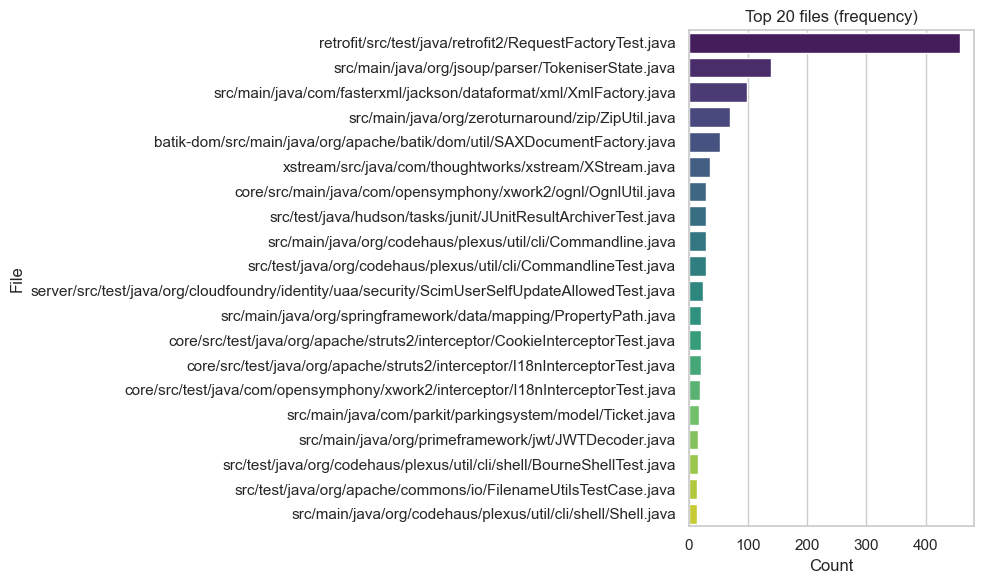

C:\Users\giakh\AppData\Local\Temp\ipykernel_18580\1968478120.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_methods.index, x=top_methods.values, palette='magma')


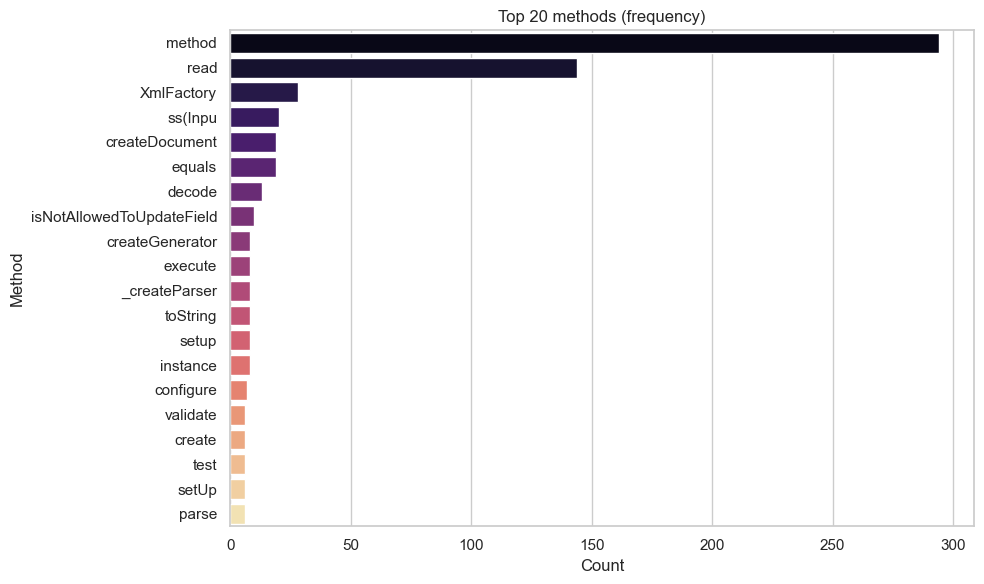

In [5]:
# Top files và methods
if 'file' in df.columns:
    top_files = df['file'].value_counts().head(20)
    plt.figure(figsize=(10,6))
    sns.barplot(y=top_files.index, x=top_files.values, palette='viridis')
    plt.title('Top 20 files (frequency)')
    plt.xlabel('Count')
    plt.ylabel('File')
    plt.tight_layout()
    plt.show()

if 'method' in df.columns:
    top_methods = df['method'].value_counts().head(20)
    plt.figure(figsize=(10,6))
    sns.barplot(y=top_methods.index, x=top_methods.values, palette='magma')
    plt.title('Top 20 methods (frequency)')
    plt.xlabel('Count')
    plt.ylabel('Method')
    plt.tight_layout()
    plt.show()

In [6]:
# Kiểm tra các nhãn 'vulnerable' vs 'fixed' nếu có cột 'version'
if 'version' in df.columns:
    # map versions to categories nếu cần
    print(df['version'].value_counts())

# Nếu có cột 'vul_id', đếm số bản ghi theo ID
if 'vul_id' in df.columns:
    print('\nTop vuln IDs:')
    print(df['vul_id'].value_counts().head(20))

version
vulnerable_other    992
vulnerable          439
fixed               434
Name: count, dtype: int64

Top vuln IDs:
vul_id
VUL4J-76      466
VUL4J-59      139
VUL4J-42       98
VUL4J-79       70
VUL4J-2        52
VUL4J-47       49
VUL4J-46       49
VUL4J-34       46
VUL4J-86-S     42
VUL4J-56       37
VUL4J-37       35
VUL4J-78       35
VUL4J-33       28
VUL4J-40       27
VUL4J-29       26
VUL4J-11       24
VUL4J-14       21
VUL4J-84-S     21
VUL4J-67       21
VUL4J-21       21
Name: count, dtype: int64


## Hiển thị mẫu code từ dataset

In [7]:
# Hiển thị một vài mẫu code ngẫu nhiên
if 'code' in df.columns:
    print("=== MẪU CODE NGẪU NHIÊN ===\n")
    samples = df.sample(min(3, len(df)))
    for idx, row in samples.iterrows():
        print(f"\n{'='*80}")
        print(f"VUL_ID: {row.get('vul_id', 'N/A')}")
        print(f"File: {row.get('file', 'N/A')}")
        print(f"Method: {row.get('method', 'N/A')}")
        print(f"Version: {row.get('version', 'N/A')}")
        print(f"Label: {row.get('label', 'N/A')}")
        print(f"\nCode:\n{'-'*80}")
        print(row.get('code', 'N/A')[:500])  # Hiển thị 500 ký tự đầu
        if len(str(row.get('code', ''))) > 500:
            print(f"\n... (còn {len(str(row.get('code', ''))) - 500} ký tự nữa)")
        print(f"{'='*80}\n")

=== MẪU CODE NGẪU NHIÊN ===


VUL_ID: VUL4J-41
File: src/main/java/org/codehaus/plexus/archiver/AbstractUnArchiver.java
Method: extractFile
Version: vulnerable
Label: 1

Code:
--------------------------------------------------------------------------------
protected void extractFile( final File srcF, final File dir, final InputStream compressedInputStream,
                                final String entryName, final Date entryDate, final boolean isDirectory,
                                final Integer mode, String symlinkDestination )
        throws IOException, ArchiverException
    {
        // Hmm. Symlinks re-evaluate back to the original file here. Unsure if this is a good thing...
        final File f = FileUtils.resolveFile( dir, entryNa

... (còn 1458 ký tự nữa)


VUL_ID: VUL4J-76
File: retrofit/src/test/java/retrofit2/RequestFactoryTest.java
Method: method
Version: vulnerable
Label: 1

Code:
--------------------------------------------------------------------------------
@G

In [8]:
# So sánh code vulnerable vs fixed cho cùng một vulnerability
if 'vul_id' in df.columns and 'version' in df.columns:
    print("=== SO SÁNH CODE: VULNERABLE vs FIXED ===\n")
    
    # Lấy một vul_id có cả version vulnerable và fixed
    for vul_id in df['vul_id'].unique()[:2]:  # Xem 2 vulnerability đầu
        vul_df = df[df['vul_id'] == vul_id]
        
        vuln_code = vul_df[vul_df['version'] == 'vulnerable']
        fixed_code = vul_df[vul_df['version'] == 'fixed']
        
        if len(vuln_code) > 0 and len(fixed_code) > 0:
            print(f"\n{'='*80}")
            print(f"VULNERABILITY ID: {vul_id}")
            print(f"File: {vuln_code.iloc[0].get('file', 'N/A')}")
            print(f"Method: {vuln_code.iloc[0].get('method', 'N/A')}")
            
            print(f"\n--- VULNERABLE CODE (label={vuln_code.iloc[0].get('label')}) ---")
            print(vuln_code.iloc[0].get('code', 'N/A')[:600])
            
            print(f"\n--- FIXED CODE (label={fixed_code.iloc[0].get('label')}) ---")
            print(fixed_code.iloc[0].get('code', 'N/A')[:600])
            print(f"{'='*80}\n")

=== SO SÁNH CODE: VULNERABLE vs FIXED ===


VULNERABILITY ID: VUL4J-1
File: src/main/java/com/alibaba/fastjson/serializer/ObjectArrayCodec.java
Method: deserialze

--- VULNERABLE CODE (label=1) ---
@SuppressWarnings({ "unchecked", "rawtypes" })
    public <T> T deserialze(DefaultJSONParser parser, Type type, Object fieldName) {
        final JSONLexer lexer = parser.lexer;
        if (lexer.token() == JSONToken.NULL) {
            lexer.nextToken(JSONToken.COMMA);
            return null;
        }

        if (lexer.token() == JSONToken.LITERAL_STRING) {
            byte[] bytes = lexer.bytesValue();
            lexer.nextToken(JSONToken.COMMA);
            return (T) bytes;
        }

        Class componentClass;
        Type componentType;
        if (type instanceof 

--- FIXED CODE (label=0) ---
@SuppressWarnings({ "unchecked", "rawtypes" })
    public <T> T deserialze(DefaultJSONParser parser, Type type, Object fieldName) {
        final JSONLexer lexer = parser.lexer;
        i

In [9]:
# Thống kê độ dài code
if 'code' in df.columns:
    df['code_length'] = df['code'].astype(str).str.len()
    df['code_lines'] = df['code'].astype(str).str.count('\n') + 1
    
    print("Thống kê độ dài code:")
    print(df[['code_length', 'code_lines']].describe())
    
    # So sánh độ dài giữa vulnerable và fixed
    if 'version' in df.columns:
        print("\n--- Độ dài theo version ---")
        print(df.groupby('version')[['code_length', 'code_lines']].mean())

Thống kê độ dài code:
        code_length   code_lines
count   1865.000000  1865.000000
mean     628.281501    15.817694
std     1110.363394    21.501422
min       17.000000     1.000000
25%      141.000000     4.000000
50%      275.000000     8.000000
75%      631.000000    18.000000
max    13858.000000   252.000000

--- Độ dài theo version ---
                  code_length  code_lines
version                                  
fixed              976.241935   24.018433
vulnerable         672.717540   16.589977
vulnerable_other   456.384073   11.888105


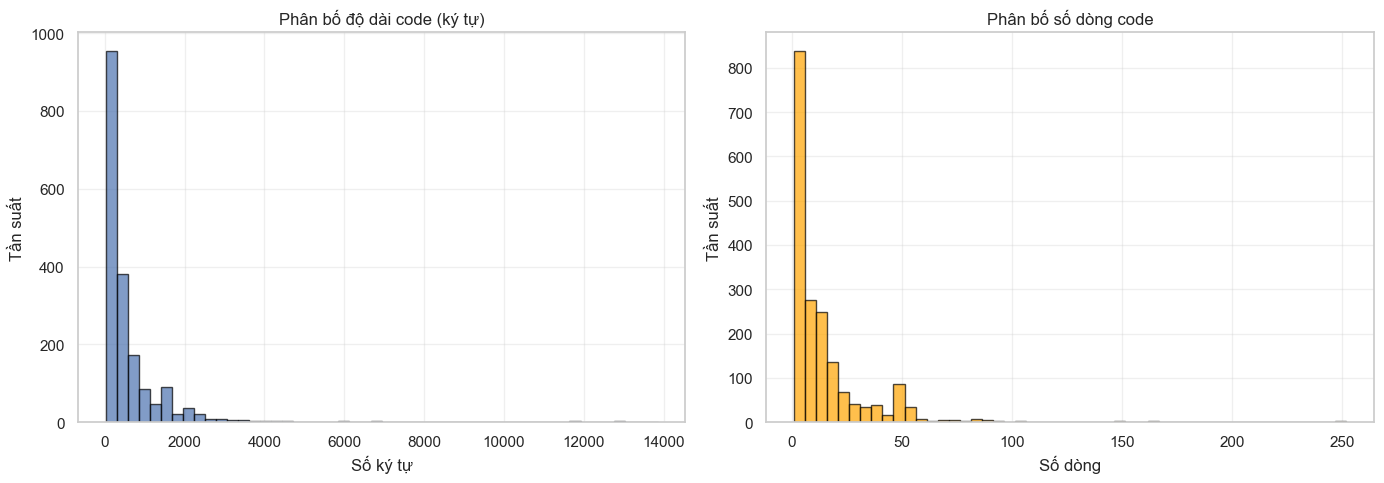

In [10]:
# Biểu đồ phân bố độ dài code
if 'code_length' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram độ dài ký tự
    axes[0].hist(df['code_length'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title('Phân bố độ dài code (ký tự)')
    axes[0].set_xlabel('Số ký tự')
    axes[0].set_ylabel('Tần suất')
    axes[0].grid(alpha=0.3)
    
    # Histogram số dòng code
    axes[1].hist(df['code_lines'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_title('Phân bố số dòng code')
    axes[1].set_xlabel('Số dòng')
    axes[1].set_ylabel('Tần suất')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [11]:
# Lưu một bản tóm tắt nhanh ra csv nếu muốn
summary = {}
summary['rows'] = len(df)
summary['columns'] = list(df.columns)
try:
    pd.DataFrame([summary]).to_csv('eda_summary.csv', index=False)
    print('Saved eda_summary.csv')
except Exception as e:
    print('Could not save summary:', e)

Saved eda_summary.csv
